In [1]:
import psycopg2
from dotenv import load_dotenv
import os 

load_dotenv()
url = os.getenv("DATABASE_URL")

In [2]:
conn = psycopg2.connect(url, sslmode="require")
cur = conn.cursor()

In [3]:
cur.execute(
    """
    SELECT DISTINCT ticker
    FROM orderbooks
    """
)
tickers = [row[0] for row in cur.fetchall()]
print(tickers)

['SR270CC6D', 'SR270CD6', 'SR270CD6A', 'SR270CD6B', 'SR270CD6D', 'SR270CD6E', 'SR270CP6', 'SR270CP6A', 'SR270CP6B', 'SR270CP6D', 'SR270CP6E', 'SR280CC6D', 'SR280CD6', 'SR280CD6A', 'SR280CD6B', 'SR280CD6D', 'SR280CD6E', 'SR280CP6', 'SR280CP6A', 'SR280CP6B', 'SR280CP6D', 'SR280CP6E', 'SR290CC6D', 'SR290CD6', 'SR290CD6A', 'SR290CD6B', 'SR290CD6D', 'SR290CD6E', 'SR290CP6', 'SR290CP6A', 'SR290CP6B', 'SR290CP6D', 'SR290CP6E', 'SR300CC6D', 'SR300CD6', 'SR300CD6A', 'SR300CD6B', 'SR300CD6D', 'SR300CD6E', 'SR300CP6', 'SR300CP6A', 'SR300CP6B', 'SR300CP6D', 'SR300CP6E', 'SR310CC6D', 'SR310CD6', 'SR310CD6A', 'SR310CD6B', 'SR310CD6D', 'SR310CD6E', 'SR310CP6', 'SR310CP6A', 'SR310CP6B', 'SR310CP6D', 'SR310CP6E', 'SR320CC6D', 'SR320CD6', 'SR320CD6A', 'SR320CD6B', 'SR320CD6D', 'SR320CD6E', 'SR320CP6', 'SR320CP6A', 'SR320CP6B', 'SR320CP6D', 'SR320CP6E', 'SR330CC6D', 'SR330CD6', 'SR330CD6A', 'SR330CD6B', 'SR330CD6D', 'SR330CD6E', 'SR330CP6', 'SR330CP6A', 'SR330CP6B', 'SR330CP6D', 'SR330CP6E', 'SR340CC6D',

In [14]:
import pandas as pd

ticker = "SR310CD6B"
columns = ["id", "ticker", "timestamp", "bids", "asks"] 

query = f"""
SELECT {', '.join(columns)}
FROM orderbooks
WHERE ticker = '{ticker}'
"""

option_df = pd.read_sql_query(query, conn)

option_df['timestamp'] = pd.to_datetime(option_df['timestamp'])
option_df.set_index('timestamp', inplace=True)

option_df['best_bid'] = option_df['bids'].apply(lambda bids: bids[0]['price'] if bids else None)
option_df['best_ask'] = option_df['asks'].apply(lambda asks: asks[0]['price'] if asks else None)
option_df['mid_price'] = option_df['best_bid'] + (option_df['best_ask'] - option_df['best_bid'])/2
option_df['spread'] = option_df['best_ask'] - option_df['best_bid']

option_df.drop(columns=['bids', 'asks', 'id'], inplace=True)
option_df = option_df[~option_df.index.duplicated(keep='first')]
option_df.drop_duplicates(inplace=True)
option_df.tail()

C:\Users\bakae\AppData\Local\Temp\ipykernel_612\986922545.py:12: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  option_df = pd.read_sql_query(query, conn)


,ticker,best_bid,best_ask,mid_price,spread
timestamp,,,,,
2026-04-08 15:17:21+00:00,SR310CD6B,9.36,9.70,9.530,0.34
2026-04-08 15:41:30+00:00,SR310CD6B,9.23,9.57,9.400,0.34
2026-04-08 15:07:31+00:00,SR310CD6B,9.42,9.60,9.510,0.18
2026-04-08 15:16:21+00:00,SR310CD6B,9.49,9.83,9.660,0.34
2026-04-08 15:54:55+00:00,SR310CD6B,8.60,9.57,9.085,0.97


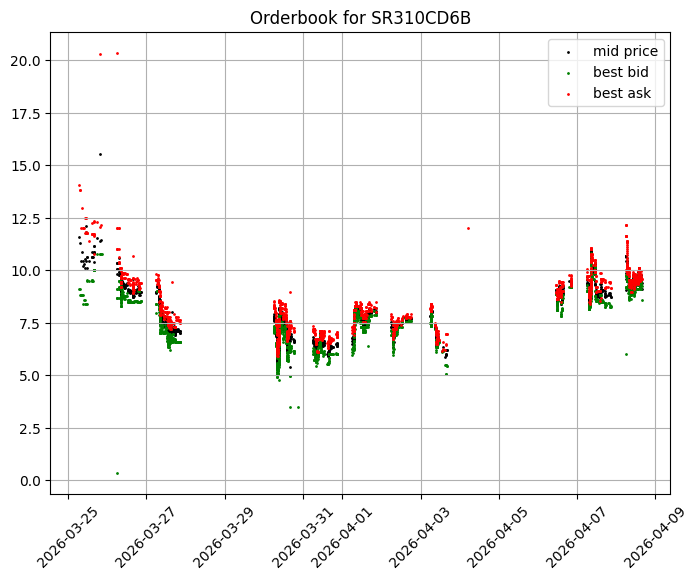

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(option_df.index, option_df['mid_price'], color="black", s=1, label="mid price")
plt.scatter(option_df.index, option_df['best_bid'], color="green", s=1, label="best bid")
plt.scatter(option_df.index, option_df['best_ask'], color="red", s=1, label="best ask")
plt.title(f"Orderbook for {ticker}")
plt.tick_params(axis='x', rotation=45)
plt.legend()
plt.grid()
plt.show()

In [48]:
columns = ["id", "ticker", "timestamp", "side", "volume", "price", "quantity"] 

query = f"""
SELECT {', '.join(columns)}
FROM orders
WHERE ticker = '{ticker}'
"""

orders_df = pd.read_sql_query(query, conn)
orders_df.head()

C:\Users\bakae\AppData\Local\Temp\ipykernel_2432\3326554322.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  orders_df = pd.read_sql_query(query, conn)


,id,ticker,timestamp,side,volume,price,quantity
0,313,SR310CD6B,2026-03-25 07:31:58+00:00,BUY,97,13,7
1,334,SR310CD6B,2026-03-25 08:30:07+00:00,BUY,84,12,7
2,335,SR310CD6B,2026-03-25 08:33:59+00:00,BUY,1003,12,83
3,364,SR310CD6B,2026-03-25 10:10:14+00:00,BUY,12,12,1
4,372,SR310CD6B,2026-03-25 10:47:47+00:00,BUY,118,11,10


Text(0.5, 0, 'date')

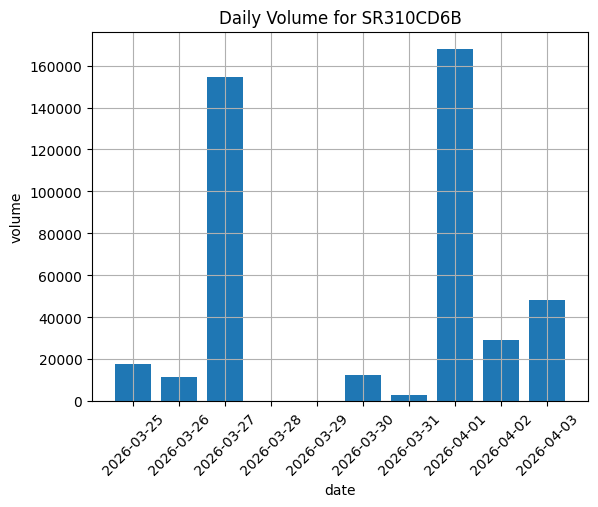

In [53]:
orders_df["timestamp"] = pd.to_datetime(orders_df["timestamp"])
orders_df["date"] = orders_df["timestamp"].dt.date

daily_volume = orders_df.groupby("date")["volume"].sum()

plt.bar(daily_volume.index, daily_volume.values)
plt.tick_params(axis='x', rotation=45)
plt.grid()
plt.title(f"Daily Volume for {ticker}")
plt.ylabel("volume")
plt.xlabel("date")